In [1]:
# AAI Task 6
# Machine Learning Model to Predict Customer Churn in a Telecommunications Company
# Instructions: Run each code block in turn, starting from the top

In [2]:
# Installing imbalance-learn library, which handles imbalanced datasets, and allows SMOTE to run
!pip install imbalanced-learn


In [3]:
# Installing required
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Installing required classes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


from imblearn.over_sampling import SMOTE

# This will print when the above is completed
print(" \nImports completed!")

 
Imports completed!


In [4]:
# CHECKING FOR MISING VALUES

# Note: The source data must be read before the missing value check in this cell
df = pd.read_csv('/content/customer_churn_clean.csv')
print("Source data read successfully! \n")

# The below checks that there are not missing values in the data, and returns the sum of all null values. (This is 0)
print(df.isnull().sum())




Source data read successfully! 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# RANDOM FOREST MODEL WITH PREDICT PROBABILITY

# READING OF CSV FILE CONTAINING DATA AND CHECKING FOR MISSING VALUES
# The source data CSV is read again here to ensure df is fresh before preprocessing
df = pd.read_csv('/content/customer_churn_clean.csv')


# ONE HOT ENCODING
# One Hot Encoding for non-binary/non-integer values. Uses CSV file loaded in previous cell as 'df'
# This converts text categories (e.g. 'Month-to-month' under contracts) into separate binary columns per unique category value
# Each binary column has a 1 in the category it represents
# The IF statements ensure  OHE is applied only to columns that are not yet split.
if 'Contract_Month-to-month' not in df.columns:
    df = pd.get_dummies(df, columns=['Contract'])
if 'InternetService_DSL' not in df.columns:
    df = pd.get_dummies(df, columns=['InternetService'])
if 'TechSupport_Yes' not in df.columns:
    df = pd.get_dummies(df, columns=['TechSupport'])
if 'OnlineSecurity_Yes' not in df.columns:
    df = pd.get_dummies(df, columns=['OnlineSecurity'])
if 'OnlineBackup_No' not in df.columns:
    df = pd.get_dummies(df, columns=['OnlineBackup'])
if 'DeviceProtection_No' not in df.columns:
    df = pd.get_dummies(df, columns=['DeviceProtection'])
if 'StreamingTV_No' not in df.columns:
    df = pd.get_dummies(df, columns=['StreamingTV'])
if 'StreamingMovies_No' not in df.columns:
    df = pd.get_dummies(df, columns=['StreamingMovies'])
if 'PaymentMethod_Electronic check' not in df.columns:
    df = pd.get_dummies(df, columns=['PaymentMethod'])

# BINARY VARIABLE MAPPING: Mapping binary Yes/No columns to 1/0 for compatibility with model
# Binary mapping two input variables
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
# Binary mapping the output variable, Churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# DROPPING ROWS WHERE CHURN (TARGET VARIABLE) IS MISSING
df = df.dropna(subset=['Churn'])

# FEATURE SELECTION (X)
# This selects input features for the model, also applying categorical variables OHE-encoded above
X = df[[
    'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
    'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
    'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No',
    'TechSupport_No', 'TechSupport_Yes', 'TechSupport_No internet service',
    'OnlineSecurity_No', 'OnlineSecurity_Yes', 'OnlineSecurity_No internet service',
    'OnlineBackup_No', 'OnlineBackup_Yes', 'OnlineBackup_No internet service',
    'DeviceProtection_No', 'DeviceProtection_Yes', 'DeviceProtection_No internet service',
    'StreamingTV_No', 'StreamingTV_Yes', 'StreamingTV_No internet service',
    'StreamingMovies_No', 'StreamingMovies_Yes', 'StreamingMovies_No internet service',
    'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
    'Partner', 'Dependents'
]]

# TARGET DEFINITION (y)
# y is an integer and has been mapped to values 1 and 0 in the binary mapping above
y = df['Churn'].astype(int)

# TRAIN/TEST SPLIT (75% TRAINING, 25% TESTING)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, train_size=0.75, random_state=42 # fixed seed for reproducibility
)

# APPLICATION OF SMOTE TO OVERSAMPLE MINORITY CLASS (CHURNED CUSTOMERS)
# This helps to balance the training data so the model learns patterns among the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# TRAINING OF RANDOM CLASSIFIER ON RESAMPLED (BALANCED) TRAINING DATA
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)


# THRESHOLD TESTING
print("  ") # Blank line for neatness
print("_________________________________________")
print("THRESHOLD TESTING")
print("Analysis of possible thresholds")

# Generates predicted churn probabilities from Random Forest Model
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Applying default threshold (0.5) to produce initial binary predictions
y_pred_rf = (y_proba_rf > 0.5).astype(int)

# The below tests different thresholds.Threshold 0.275 was selected after testing
# Iterates over candidate thresholds, printing precision and recall figures for each
for threshold in [0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.40]:
    y_pred_t = (y_proba_rf > threshold).astype(int)
    report = classification_report(y_test, y_pred_t, target_names=['No Churn', 'Churn'], output_dict=True)
    print(f"Threshold {threshold}: Precision={report['Churn']['precision']:.4f}, Recall={report['Churn']['recall']:.4f}")

# Defining the selected threshold based on the analysis above
selected_threshold= 0.275


# APPLICATION OF SELECTED THRESHOLD TO GENERATE BINARY PREDICTIONS
print("  ") # Blank line for neatness
print("_________________________________________")
print(f"Classification of Selected Threshold: {selected_threshold}")

# Applying threshold (0.275) to convert probabeilities to binary predictions
y_pred_t = (y_proba_rf >selected_threshold).astype(int)

# Printing overall model accuracy figures based o
print(f'Accuracy: {accuracy_score(y_test, y_pred_t):.2%}')

print(" ") # Blank line for neatness
print("_________________________________________")

# Printing full classification report
print("Analysis Notes")
print(" ")
print(classification_report(y_test, y_pred_t))

# Printing brief evaluation notes
print("_________________________________________")
print("Evaluation notes")
print(" ")
print("The train/test split was 75:25. \nAt the selected threshold of 0.275, Churn Precision is above 51%, and Churn Recall is optimised at 80%")

  
_________________________________________
THRESHOLD TESTING
Analysis of possible thresholds
Threshold 0.15: Precision=0.4415, Recall=0.8894
Threshold 0.175: Precision=0.4528, Recall=0.8706
Threshold 0.2: Precision=0.4583, Recall=0.8372
Threshold 0.225: Precision=0.4824, Recall=0.8288
Threshold 0.25: Precision=0.4981, Recall=0.8163
Threshold 0.275: Precision=0.5114, Recall=0.7975
Threshold 0.3: Precision=0.5186, Recall=0.7557
Threshold 0.325: Precision=0.5219, Recall=0.7203
Threshold 0.35: Precision=0.5423, Recall=0.6952
Threshold 0.375: Precision=0.5517, Recall=0.6681
Threshold 0.4: Precision=0.5618, Recall=0.6451
  
_________________________________________
Classification of Selected Threshold: 0.275
Accuracy: 73.76%
 
_________________________________________
Analysis Notes
 
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1282
           1       0.51      0.80      0.62       479

    accuracy                           0.74 

[[917 365]
 [ 97 382]]


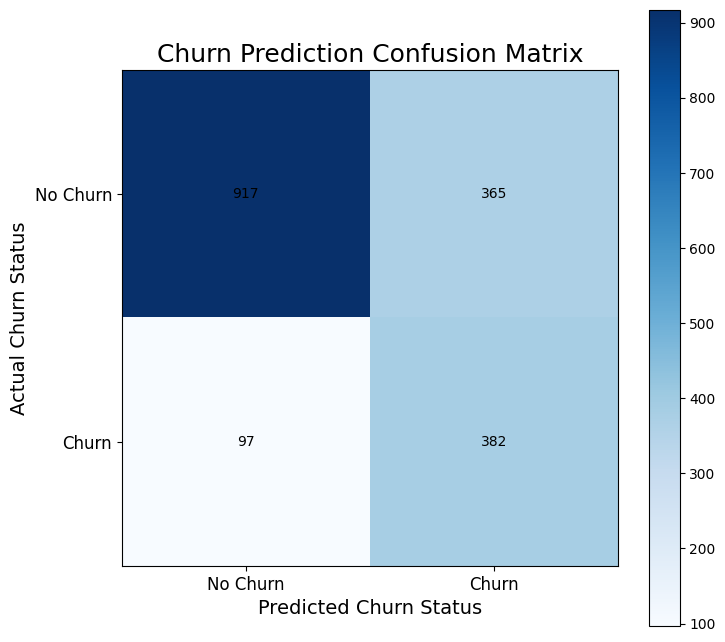

In [ ]:
# CONFUSION MATRIX WITH MATPLOTLIB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Apply selected threshold to generate final binary predictions for evaluation
y_pred = (rf_model.predict_proba(X_test)[:, 1] > selected_threshold).astype(int)

# Computing and printing  raw confusion matrix figures
matrix = confusion_matrix(y_test, y_pred)
print(matrix)

# CREATING VISUALISATION OF CONFUSION MATRIX
# Sizing of visualisation
fig, ax = plt.subplots(figsize=(8, 8))

# Setting monochrome-style visuals
disp = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["No Churn", "Churn"]
)

# Setting a white to blue color scale
disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True
)

# Labels and font styling for axes
ax.set_xlabel("Predicted Churn Status", fontsize=14)
ax.set_ylabel("Actual Churn Status", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# Setting a title to appear above the confusion matrix and a font size for the title
plt.title("Churn Prediction Confusion Matrix", fontsize=18)

# Setting black font color for optimum readability
for text in disp.text_.ravel():
    text.set_color("black")

# DISPLAYING CONFUSION MATRIX
plt.show()

In [ ]:
# This shows importance of each factor in the result
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

TotalCharges                               0.135384
MonthlyCharges                             0.116552
tenure                                     0.116011
Contract_Month-to-month                    0.092185
OnlineSecurity_No                          0.080369
PaymentMethod_Electronic check             0.056211
TechSupport_No                             0.055754
OnlineBackup_No                            0.040867
InternetService_Fiber optic                0.029658
Partner                                    0.022424
Dependents                                 0.021802
DeviceProtection_No                        0.020475
OnlineBackup_Yes                           0.015872
Contract_One year                          0.015470
Contract_Two year                          0.015270
OnlineSecurity_Yes                         0.014267
TechSupport_Yes                            0.014117
PaymentMethod_Bank transfer (automatic)    0.013298
PaymentMethod_Credit card (automatic)      0.013072
SeniorCitize